In [256]:
#-----
#Name: Dylan Shaffer
#Course: COSC 522
#Module: M4
#----



In [257]:
######################## Start of Code to Not Modify ################################

In [258]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

#Show fewer digits to improve readability
np.set_printoptions(precision=3, suppress=True)


In [259]:
#download the "MTCars" database as a TSV file with no header row
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
dataset = dataset.dropna()#drop cars with incomplete data
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [260]:
#adding nation of origin to as binary variable
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


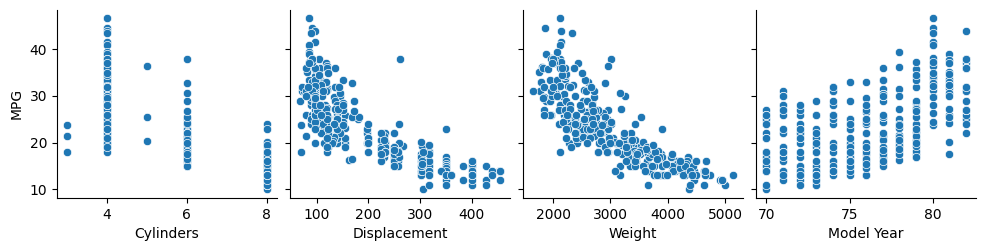

In [261]:
#split into train and test sets and plot
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

pp = sns.pairplot(data=train_dataset,
                  x_vars=['Cylinders', 'Displacement', 'Weight','Model Year'],
                  y_vars=['MPG'])

plt.savefig('plots-four-features.pdf')
plt.savefig('plots-four-features.svg')
plt.savefig('plots-four-features-dpi-72.png',dpi=72)
plt.savefig('plots-four-features-dpi-300.png',dpi=300)


In [262]:
#create training features and labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

#use MPG as regression targets
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

#train sklearn linear model
linear_model = LinearRegression().fit(train_features, train_labels)

In [263]:
print(linear_model.score(train_features, train_labels))
print(linear_model.score(test_features, test_labels))

0.8162658991904448
0.8442412485817236


In [264]:
#test first row of test_features prediction
print(test_labels.iloc[0])
linear_model.predict([test_features.iloc[0]])

15.0


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([np.float64(13.255979916476921)], dtype=object)

In [265]:
#get coef and intercept
print(linear_model.coef_)
print(linear_model.intercept_)

[-0.464  0.023 -0.036 -0.006 -0.095  0.796  0.819  1.146 -1.965]
-14.863633704016248


In [266]:
chart_data = pd.DataFrame()
chart_data["Index"] = pd.DataFrame(range(0,len(test_features)))
chart_data["Predicted"] = pd.DataFrame(linear_model.predict(test_features))
chart_data["True MPG"] = pd.DataFrame(test_labels.to_list())
chart_data["ABS Error"] = abs(chart_data["True MPG"] - chart_data["Predicted"])
chart_data["Weight"] = pd.DataFrame(test_features["Weight"].to_list())
#combine index, test_labels, and predicted
# chart_data = pd.join([index,predicted,test_labels], keys=["index","predict","label"])

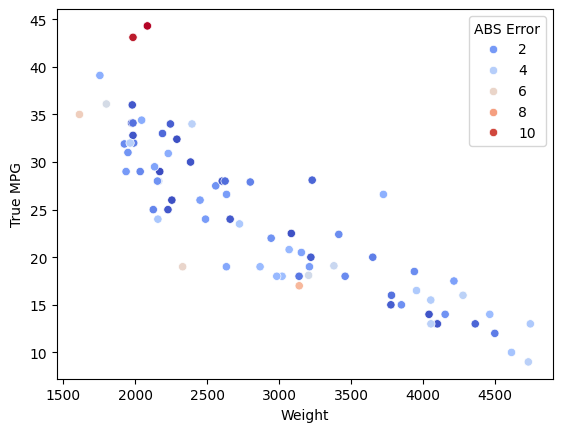

In [267]:
#print out the test set
pp = sns.scatterplot(data=chart_data,
                  x='Weight',
                  y='True MPG',hue="ABS Error",palette=sns.color_palette("coolwarm", as_cmap=True))
plt.savefig('plots-lm-test-output.pdf')
plt.savefig('plots-lm-test-output.svg')
plt.savefig('plots-lm-test-output-dpi-72.png',dpi=72)
plt.savefig('plots-lm-test-output-dpi-300.png',dpi=300)

In [268]:
#increasing horsepower by 200 in the first row predicts MPG to a lower amount
weight_offset = 300
print("With",weight_offset,"more lbs weight, MPG predicted at",linear_model.predict([[8,390,190,3850+weight_offset,8.5,70,0,0,1]]))

#increasing horsepower by 2000 in the first row predicts MPG to a lower amount, which is negative
weight_offset = 3000
print("With",weight_offset,"more lbs weight, MPG predicted at",linear_model.predict([[8,390,190,3850+weight_offset,8.5,70,0,0,1]]))

With 300 more lbs weight, MPG predicted at [11.437]
With 3000 more lbs weight, MPG predicted at [-4.938]


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [269]:
######################## End of Code to Not Modify ################################

In [270]:
#Question 1:
# Our M4 example uses 80% of our data for training and %20 for training.
# Change this to a 20% train and 80% test.
#What happens to the prediction of the first row of data (which was previously 13.256)?


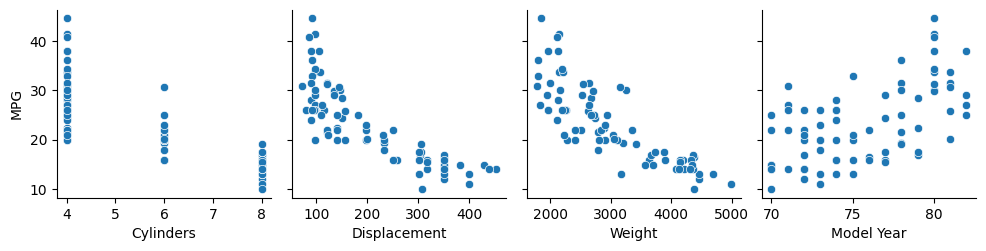

In [271]:
# code that addresses Question 1
#split into train and test sets and plot
train_dataset = dataset.sample(frac=0.2, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

pp = sns.pairplot(data=train_dataset,
                  x_vars=['Cylinders', 'Displacement', 'Weight','Model Year'],
                  y_vars=['MPG'])

plt.savefig('plots-four-features.pdf')
plt.savefig('plots-four-features.svg')
plt.savefig('plots-four-features-dpi-72.png',dpi=72)
plt.savefig('plots-four-features-dpi-300.png',dpi=300)

In [272]:
#create training features and labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

#use MPG as regression targets
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

#train sklearn linear model
linear_model = LinearRegression().fit(train_features, train_labels)

In [273]:
#test first row of test_features prediction
print(test_labels.iloc[0])
linear_model.predict([test_features.iloc[0]])

18.0


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([np.float64(15.29154165643713)], dtype=object)

In [274]:
#Answer 1:
# The predicition increases from 13.256 to 15.292, which is closer to the actual value of 18 mpg.

In [275]:
#Question 2:
# Reduce the number of features in our linear regression example to two (you may pick any two).
# What happens to the prediction of the first row of data (which was previously 13.256?

In [276]:
# code that addresses Question 2
#download the "MTCars" database as a TSV file with no header row
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Weight']

dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
dataset = dataset.dropna()#drop cars with incomplete data
dataset.tail()

,,,,,MPG,Cylinders,Weight
27.0,4,140.0,86.0,2790.0,15.6,82,1
44.0,4,97.0,52.0,2130.0,24.6,82,2
32.0,4,135.0,84.0,2295.0,11.6,82,1
28.0,4,120.0,79.0,2625.0,18.6,82,1
31.0,4,119.0,82.0,2720.0,19.4,82,1


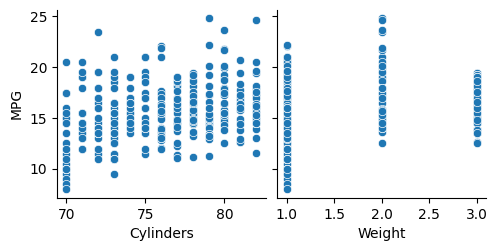

In [277]:
#split into train and test sets and plot
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

pp = sns.pairplot(data=train_dataset,
                  x_vars=['Cylinders', 'Weight'],
                  y_vars=['MPG'])

plt.savefig('plots-four-features.pdf')
plt.savefig('plots-four-features.svg')
plt.savefig('plots-four-features-dpi-72.png',dpi=72)
plt.savefig('plots-four-features-dpi-300.png',dpi=300)

In [278]:
#create training features and labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

#use MPG as regression targets
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

#train sklearn linear model
linear_model = LinearRegression().fit(train_features, train_labels)

In [279]:
#test first row of test_features prediction
print(test_labels.iloc[0])
linear_model.predict([test_features.iloc[0]])

8.5


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14.084])

In [280]:
#Answer 2:
# Assuming we are back to training on 80% of the data, the prediction increases from 13.256 to 14.084 after training on only cylinders and weight. This prediction is closer to the real mpg of 18 for the first row of data.

In [281]:
#Question 3:
# Reduce the number of features in our linear regression example to two (you may pick any two).
# What happens to the prediction of the first row of data (which was previously 13.256?

In [282]:
# code that addresses Question 3

In [283]:
#Answer 3:
# Skipping this question per discord discussion

In [284]:
#Question 4:
# Instead of predicting MPG, predict Horsepower.
# What is the prediction compared to the real value of the first elment of the test set?


In [285]:
# code that addresses Question 4
#download the "MTCars" database as a TSV file with no header row
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
dataset = dataset.dropna()#drop cars with incomplete data
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [286]:
#adding nation of origin to as binary variable
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


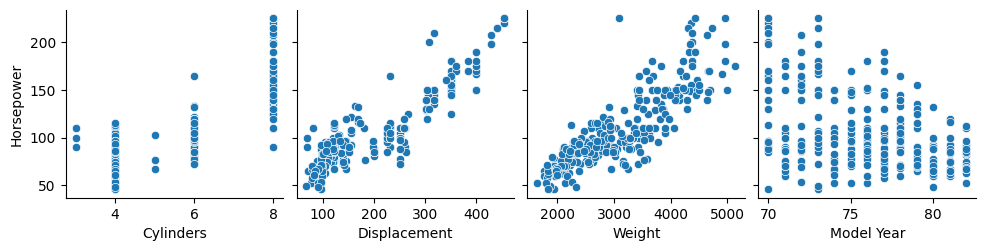

In [287]:
#split into train and test sets and plot
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

pp = sns.pairplot(data=train_dataset,
                  x_vars=['Cylinders', 'Displacement', 'Weight','Model Year'],
                  y_vars=['Horsepower'])

plt.savefig('plots-four-features.pdf')
plt.savefig('plots-four-features.svg')
plt.savefig('plots-four-features-dpi-72.png',dpi=72)
plt.savefig('plots-four-features-dpi-300.png',dpi=300)


In [288]:
#create training features and labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

#use Horsepower as regression targets
train_labels = train_features.pop('Horsepower')
test_labels = test_features.pop('Horsepower')

#train sklearn linear model
linear_model = LinearRegression().fit(train_features, train_labels)

In [289]:
#test first row of test_features prediction
print(test_labels.iloc[0])
linear_model.predict([test_features.iloc[0]])

190.0


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([np.float64(181.59594152533714)], dtype=object)

In [290]:
#Answer 4:
# The model predicits 181.596 horsepower, which is higher than the real value of 130 horsepower.

In [291]:
#Question 5:
# Add normalization and use the prediction code you already have. Does our model work better or worse? Why?


In [292]:
# code that addresses Question 5
# code that addresses Question 4
#download the "MTCars" database as a TSV file with no header row
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)
dataset = dataset.dropna()#drop cars with incomplete data
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [293]:
#adding nation of origin to as binary variable
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


In [294]:
# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data
normalized_data = scaler.fit_transform(dataset)

# Convert the normalized data back to a DataFrame with the same column names
normalized_data = pd.DataFrame(normalized_data, columns=dataset.columns)  # <-- fixed

In [295]:
# Reset index on the full dataset FIRST, before splitting
dataset = dataset.reset_index(drop=True)

train_dataset = normalized_data.sample(frac=0.8, random_state=0)
test_dataset = normalized_data.drop(train_dataset.index)

scaler = MinMaxScaler()

train_normalized = pd.DataFrame(scaler.fit_transform(train_dataset), columns=dataset.columns)
test_normalized = pd.DataFrame(scaler.transform(test_dataset), columns=dataset.columns)

In [296]:
#create training features and labels
train_features = train_dataset.copy()
test_features = test_dataset.copy()

#use MPG as regression targets
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

#train sklearn linear model
linear_model = LinearRegression().fit(train_features, train_labels)

In [297]:
#test first row of test_features prediction
print(test_labels.iloc[0])
linear_model.predict([test_features.iloc[0]])

0.15957446808510636


c:\Users\Dylan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.113])

In [298]:
chart_data = pd.DataFrame()
chart_data["Index"] = pd.DataFrame(range(0,len(test_features)))
chart_data["Predicted"] = pd.DataFrame(linear_model.predict(test_features))
chart_data["True MPG"] = pd.DataFrame(test_labels.to_list())
chart_data["ABS Error"] = abs(chart_data["True MPG"] - chart_data["Predicted"])
chart_data["Weight"] = pd.DataFrame(test_features["Weight"].to_list())
#combine index, test_labels, and predicted
# chart_data = pd.join([index,predicted,test_labels], keys=["index","predict","label"])

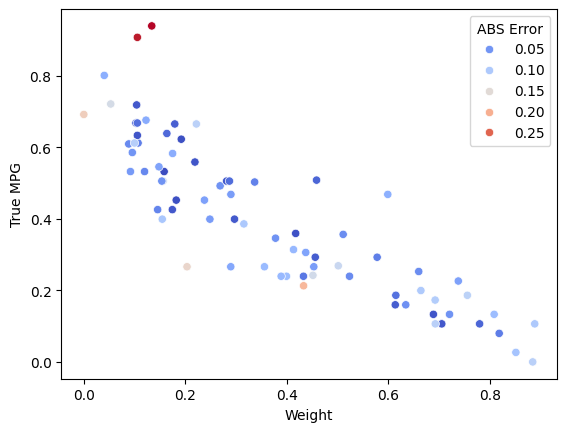

In [299]:
#print out the test set
pp = sns.scatterplot(data=chart_data,
                  x='Weight',
                  y='True MPG',hue="ABS Error",palette=sns.color_palette("coolwarm", as_cmap=True))
plt.savefig('plots-lm-test-output.pdf')
plt.savefig('plots-lm-test-output.svg')
plt.savefig('plots-lm-test-output-dpi-72.png',dpi=72)
plt.savefig('plots-lm-test-output-dpi-300.png',dpi=300)

In [ ]:
#Answer 5:
# After normalization, the model performs roughly the same as before. This is because linear regression is not sensitive to the scale of the features, so normalizing the data does not significantly affect the model's performance.